# SBDR - Data Loading & Exploration

This notebook handles initial data loading, inspection, and basic exploration
for the Sentimental-Behavioral Debt Recovery project.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


In [4]:
pwd

'/Users/rajdeeproy/UMBC/ObsidianVaults/Interview Prep/Projects/SBDR/notebooks'

In [7]:
!pip install xlrd

## 1. Data Loading & Metadata

### Dataset: UCI Credit Card Default
**Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients)  
**Dimensions:** 30,000 rows × 25 columns  
**Role:** Primary anchor dataset for BiLSTM architecture and target merging.

---

### Variable Dictionary

#### Target Variable
* **default payment next month:** Binary response (Yes = 1, No = 0)

#### Explanatory Variables (Features)
| ID | Feature | Description | Coding / Scale |
| :--- | :--- | :--- | :--- |
| **X1** | **LIMIT_BAL** | Amount of given credit (NT dollar) | Includes individual & family credit |
| **X2** | **SEX** | Gender | 1 = Male; 2 = Female |
| **X3** | **EDUCATION** | Education Level | 1 = Grad School; 2 = University; 3 = High School; 4 = Others |
| **X4** | **MARRIAGE** | Marital Status | 1 = Married; 2 = Single; 3 = Others |
| **X5** | **AGE** | Age | Years |

#### Temporal Features (April – September 2005)

| Feature Group | Column Names | Description |
| :--- | :--- | :--- |
| **Repayment Status** | `PAY_0` to `PAY_6` | **X6 - X11:** -1 = pay duly; 1 = delay 1 mo; ... 9 = delay 9+ mos |
| **Bill Statement** | `BILL_AMT1` to `BILL_AMT6` | **X12 - X17:** Amount of bill statement (NT dollar) |
| **Previous Payment** | `PAY_AMT1` to `PAY_AMT6` | **X18 - X23:** Amount of previous payment (NT dollar) |

> **Note on Temporal Ordering:** `PAY_0`, `BILL_AMT1`, and `PAY_AMT1` represent the most recent month (September), while `PAY_6`, `BILL_AMT6`, and `PAY_AMT6` represent the oldest month (April).l, 2005.

In [28]:
df = pd.read_excel("../data/raw/default of credit card clients.xls", header=1)

## Basic Exploration

In [27]:
df.head(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [9]:
df.shape

(30000, 25)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [11]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [14]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [15]:
print(f"\n=== Null Values ===")
print(df.isnull().sum().sum(), "total nulls")


=== Null Values ===
0 total nulls


## Target Variable: `default payment next month`
This is what we're ultimately predicting. Let's see how balanced the classes are — imbalanced data will affect our model training later.

In [17]:
target = df['default payment next month'].value_counts()
print(f"No Default (0): {target[0]} ({target[0]/len(df)*100:.1f}%)")
print(f"Default (1):    {target[1]} ({target[1]/len(df)*100:.1f}%)")

No Default (0): 23364 (77.9%)
Default (1):    6636 (22.1%)


/var/folders/sq/5sx7g2w17zjc98wp4_pf62fw0000gn/T/ipykernel_52668/3021922237.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Default', 'Default'])


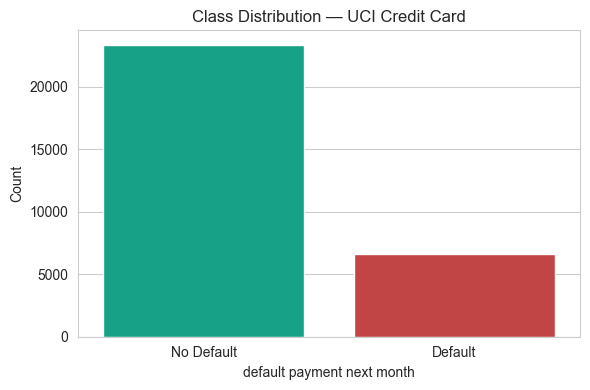

[Text(0, 0, 'No Default'), Text(1, 0, 'Default')]

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='default payment next month', data=df, hue='default payment next month', palette=['#00b894', '#d63031'], legend=False, ax=ax)
ax.set_xticklabels(['No Default', 'Default'])
ax.set_title('Class Distribution — UCI Credit Card')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
# for the tick labels warning
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Default', 'Default'])

## Payment History: PAY_0 to PAY_6
These 6 columns are the heartbeat of our project — they feed the BiLSTM. Each value represents how late a customer was that month:
- `-1` = paid on time
- `0` = minimum payment
- `1` = 1 month late
- `2+` = progressively worse

In [23]:
# Payment status distribution across 6 months
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
#Creating a list as we can easily apply the operations on all 6 cols simultaneously.

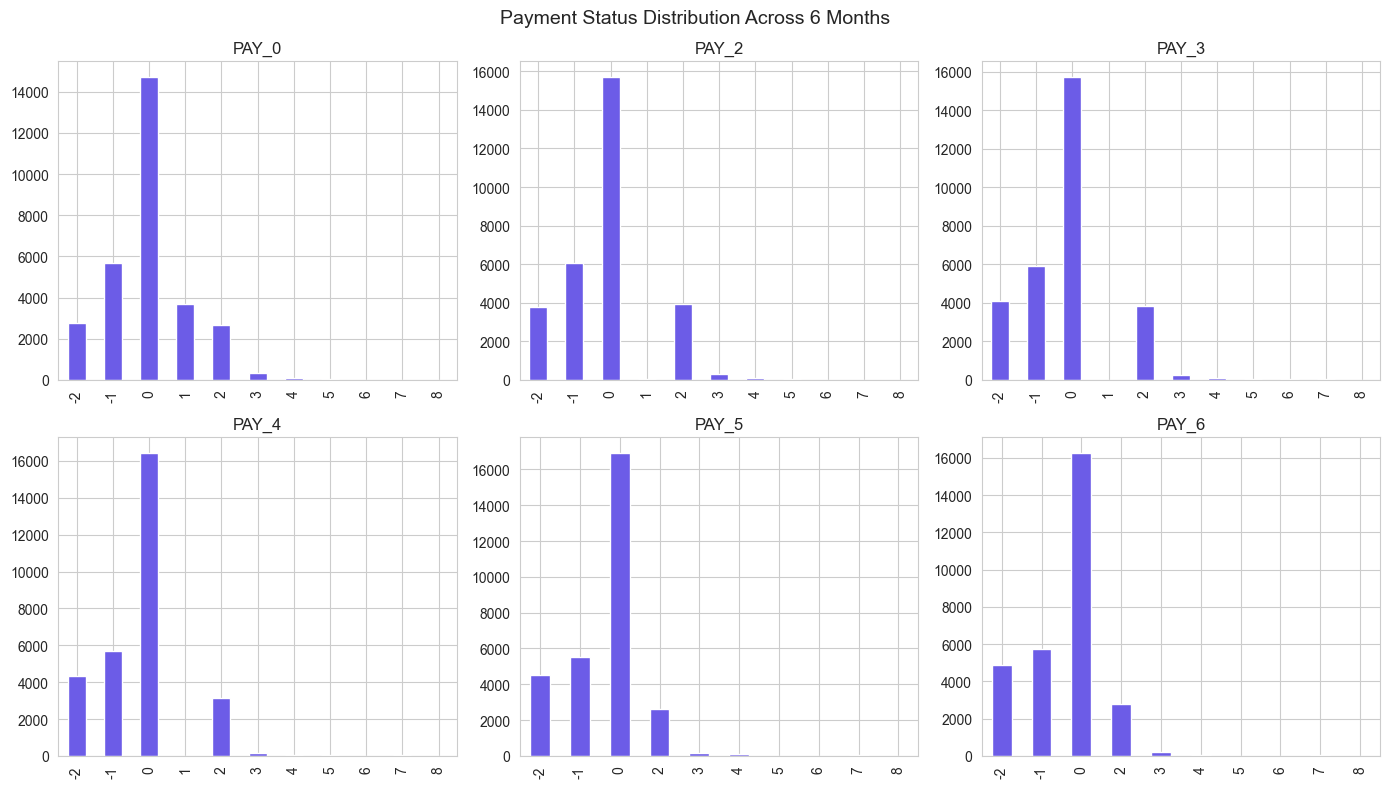

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(pay_cols):
    df[col].value_counts().sort_index().plot(kind='bar', ax=axes[i], color='#6c5ce7')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Payment Status Distribution Across 6 Months', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
# How many customers got progressively worse?
print("=== Mean payment status per month ===")
print(df[pay_cols].mean().round(3))

=== Mean payment status per month ===
PAY_0   -0.017
PAY_2   -0.134
PAY_3   -0.166
PAY_4   -0.221
PAY_5   -0.266
PAY_6   -0.291
dtype: float64


The columns go PAY_6 (oldest) → PAY_0 (most recent). 

The average is climbing toward zero over time. That means as a group, customers are drifting from on-time (-1) toward late payments (0 and above).

## Bill Amounts & Payment Amounts (6-Month Trend)
`BILL_AMT1–6` = how much the customer owed each month

`PAY_AMT1–6` = how much they actually paid

The gap between these two tells us if someone is barely keeping up or falling behind.

In [29]:
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

# Average bill vs average payment over 6 months
avg_bill = df[bill_cols].mean()
avg_pay = df[pay_amt_cols].mean()


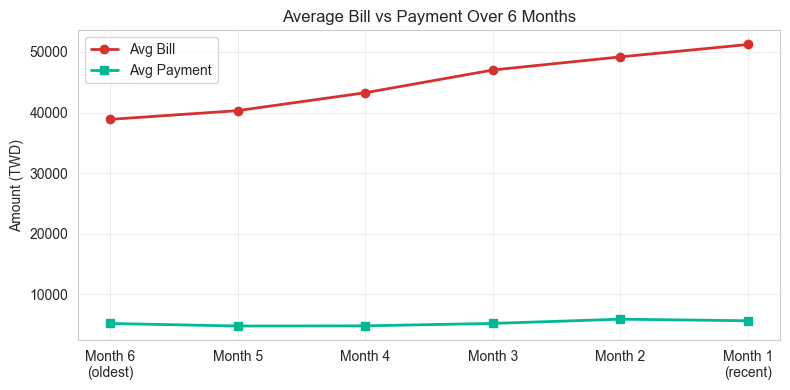

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
months = ['Month 6\n(oldest)', 'Month 5', 'Month 4', 'Month 3', 'Month 2', 'Month 1\n(recent)']
ax.plot(months, avg_bill.values[::-1], marker='o', label='Avg Bill', color='#d63031', linewidth=2)
ax.plot(months, avg_pay.values[::-1], marker='s', label='Avg Payment', color='#00b894', linewidth=2)
ax.set_title('Average Bill vs Payment Over 6 Months')
ax.set_ylabel('Amount (TWD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# The gap — are people paying less than they owe?
print("Avg Payment as % of Bill")
for i in range(6):
    ratio = df[pay_amt_cols[i]].mean() / df[bill_cols[i]].mean() * 100
    print(f"Month {6-i}: {ratio:.1f}%")

Avg Payment as % of Bill
Month 6: 11.1%
Month 5: 12.0%
Month 4: 11.1%
Month 3: 11.2%
Month 2: 11.9%
Month 1: 13.4%


**Bills going up (red line climbing):** Customers are spending more each month — their credit card balance keeps growing. Could be because they're relying more on credit, or interest is piling up on unpaid balances.

**Payments staying flat (green line stuck):** They're paying roughly the same small amount every month regardless of how much they owe. Likely just the minimum payment or whatever they can afford.

**What this means in real life:** Imagine you owe 39K in month 1, you pay 5K. Next month you owe 43K (old balance + interest + new spending), you still pay 5K. By month 6, you owe 51K but you're still only paying 5K.

The debt is snowballing. That's the **financial spiral** — and this is exactly why this dataset is perfect for our BiLSTM. The model will learn to spot this pattern (growing gap = incoming default) and flag the customer for Tier 2 or 3 intervention before they hit Tier 4.

## Demographics
Quick look at AGE, SEX, EDUCATION, MARRIAGE — we need this for:
1. XGBoost features (Phase B)
2. Fairness audit (Phase C) — making sure "compassion" isn't biased by demographics

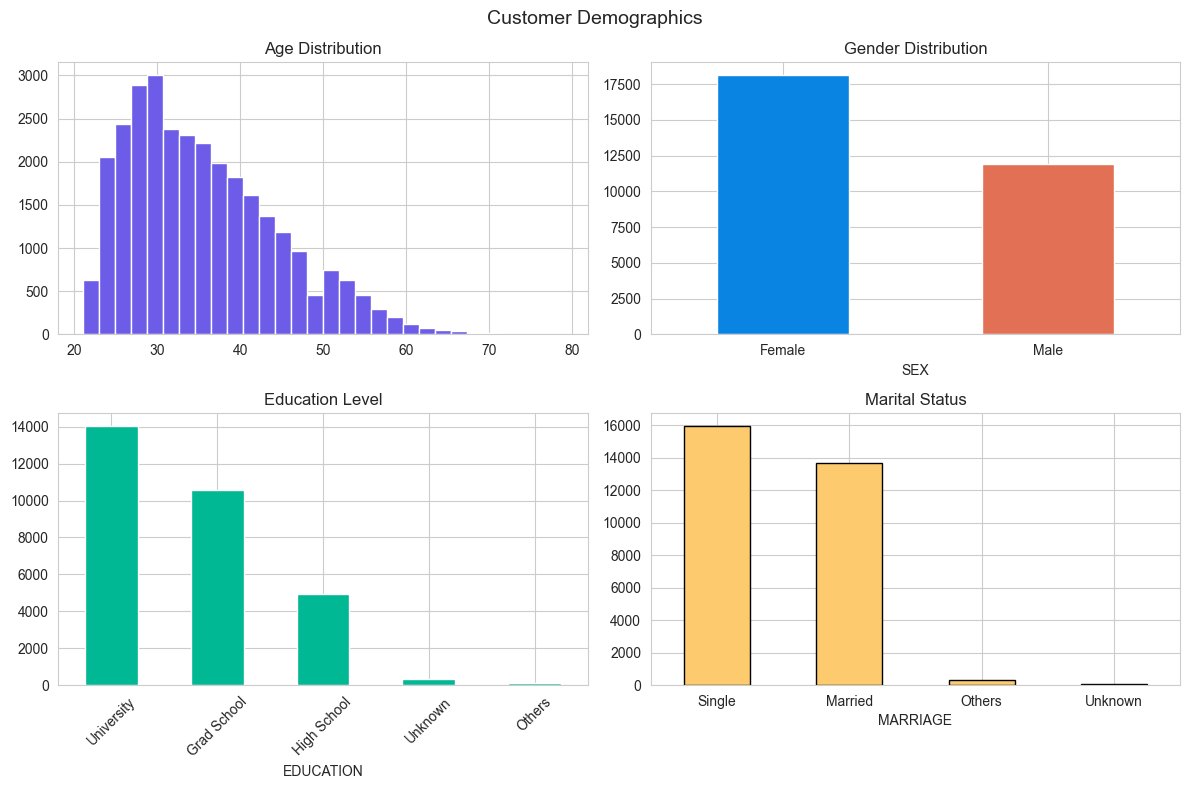

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Age
df['AGE'].hist(bins=30, ax=axes[0,0], color='#6c5ce7', edgecolor='white')
axes[0,0].set_title('Age Distribution')

# Sex (1=Male, 2=Female)
df['SEX'].value_counts().plot(kind='bar', ax=axes[0,1], color=['#0984e3','#e17055'])
axes[0,1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0,1].set_title('Gender Distribution')

# Education (1=Grad, 2=University, 3=High School, 4=Others)
edu_labels = {1:'Grad School', 2:'University', 3:'High School', 4:'Others', 5:'Unknown', 6:'Unknown', 0:'Unknown'}
df['EDUCATION'].map(edu_labels).value_counts().plot(kind='bar', ax=axes[1,0], color='#00b894')
axes[1,0].set_title('Education Level')
axes[1,0].tick_params(axis='x', rotation=45)

# Marriage (1=Married, 2=Single, 3=Others)
mar_labels = {1:'Married', 2:'Single', 3:'Others', 0:'Unknown'}
df['MARRIAGE'].map(mar_labels).value_counts().plot(kind='bar', ax=axes[1,1], color='#fdcb6e', edgecolor='black')
axes[1,1].set_title('Marital Status')
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('Customer Demographics', fontsize=14)
plt.tight_layout()
plt.show()

**What each chart tells us:**

- **Age:** Most customers are **25–35 years old**. Young working professionals — makes sense for credit card users. Skews young, drops off sharply after 50.

- **Gender:** More **females (approx 18K) than males (approx 12K)**. 60/40 split. Important to note for fairness audit later — we need to make sure our model isn't harsher on one gender.

- **Education:** Majority are **University or Grad School** educated. Very few high school only. This is a relatively educated customer base.

- **Marriage:** Roughly **even split between Single and Married**. Tiny "Others" and "Unknown" categories — we might merge these during cleanup.

**Why this matters for the project:**

1. **XGBoost features** — age, education, marital status will be input features alongside the financial data
2. **Fairness audit (Phase C)** — we'll check if the model is recommending Tier 4 (legal action) disproportionately to one gender, age group, or education level. If it is, that's bias we need to fix
3. **The gender imbalance** (60/40) means we need to be careful — the model might learn "female patterns" better simply because there's more data

This is also why we listed SHAP + demographic parity checks in the roadmap. The whole point of "compassionate AI" falls apart if the compassion isn't distributed fairly with no bias.


## Correlation with Default
Which features have the strongest relationship with defaulting? This tells us what signals matter most — and validates whether payment history (our BiLSTM input) is actually predictive.

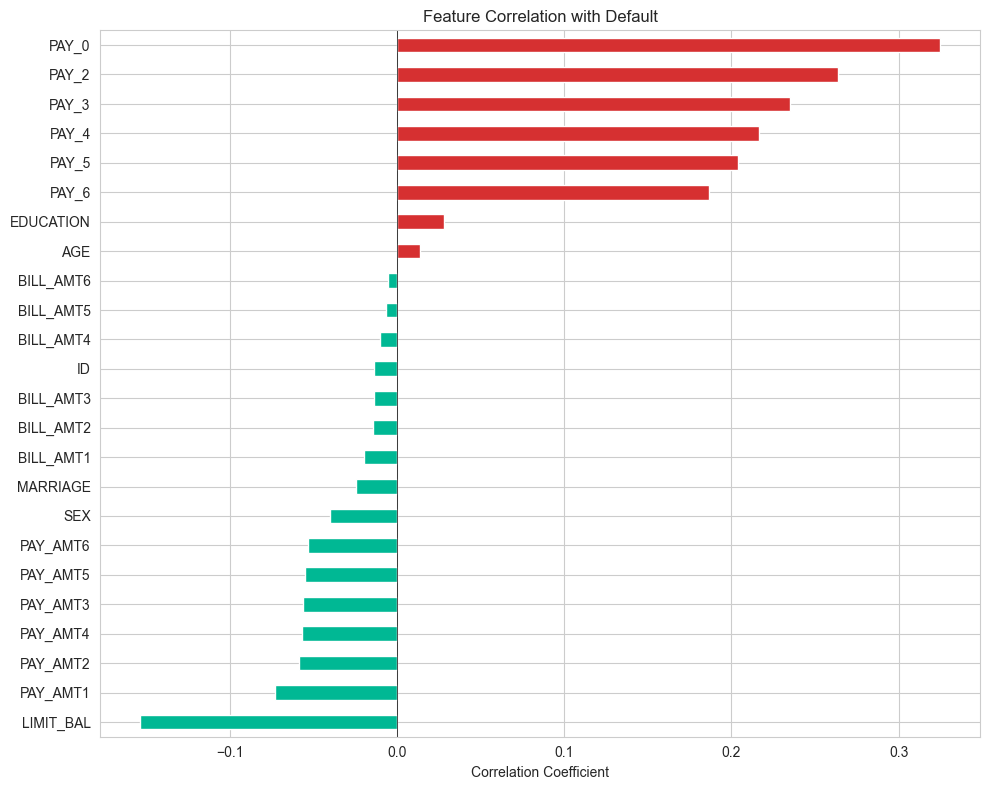

In [34]:
# Correlation with target
corr = df.corr()['default payment next month'].drop('default payment next month').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
corr.plot(kind='barh', color=[('#d63031' if v > 0 else '#00b894') for v in corr.values], ax=ax)
ax.set_title('Feature Correlation with Default')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

In [35]:
# Top 5 positive (push toward default) and negative (push away from default)
print("=== Top 5 — Most Likely to Default ===")
print(corr.tail(5).round(3))
print("\n=== Top 5 — Least Likely to Default ===")
print(corr.head(5).round(3))

=== Top 5 — Most Likely to Default ===
PAY_5    0.204
PAY_4    0.217
PAY_3    0.235
PAY_2    0.264
PAY_0    0.325
Name: default payment next month, dtype: float64

=== Top 5 — Least Likely to Default ===
LIMIT_BAL   -0.154
PAY_AMT1    -0.073
PAY_AMT2    -0.059
PAY_AMT4    -0.057
PAY_AMT3    -0.056
Name: default payment next month, dtype: float64


---
**Correlation coefficient** is just a number between -1 and +1 that says "when this feature goes up, does default go up or down?"

- **+1** = they move together perfectly (feature goes up → default goes up)
- **0** = no relationship at all
- **-1** = they move opposite (feature goes up → default goes down)

**Why we need it:** Before building models, we want to know which features actually *matter*. No point feeding 25 columns into XGBoost if 15 of them have zero relationship with default.

---

**Output explaination:**

**Red bars (positive = pushes toward default):**
- `PAY_0` (0.325) is the strongest predictor — how late you are *right now* matters most
- `PAY_2` through `PAY_6` (0.19–0.26) — your entire payment history matters, but recent months matter more
- This is huge for us — it **validates our BiLSTM approach**. Payment sequences ARE the most predictive signal.

**Green bars (negative = pushes away from default):**
- `LIMIT_BAL` (-0.154) — higher credit limit = less likely to default. Makes sense — banks give higher limits to trustworthy customers
- `PAY_AMT1–6` (-0.05 to -0.07) — people who pay more each month are less likely to default. Obvious but confirmed.

**The big takeaway:** Demographics (`AGE`, `SEX`, `MARRIAGE`) have near-zero correlation — they barely matter on their own. But payment behavior (`PAY_0–6`) dominates. This means our model's power will come from the **BiLSTM learning payment sequences**, not from demographics. Exactly what we designed for.


## Feature Engineering
These are the custom features we designed for SBDR. They compress 6 months of raw data into meaningful signals that our models can use directly.

- **Spending Volatility** — how unstable is their spending?
- **Payment Ratio Trend** — are they paying a smaller % of their bill over time?
- **Delinquency Acceleration** — how fast are they getting worse?

In [37]:
# 1. Spending Volatility — std dev of bill amounts across 6 months
df['spending_volatility'] = df[bill_cols].std(axis=1)

print("Spending Volatility")
print(df['spending_volatility'].describe().round(2))

Spending Volatility
count     30000.00
mean      12077.79
std       20302.15
min           0.00
25%        1549.94
50%        4579.66
75%       14352.26
max      647788.05
Name: spending_volatility, dtype: float64


In [39]:
# 2. Payment Ratio — how much of the bill they are actually paying each month
for i in range(1, 7):
    bill = f'BILL_AMT{i}'
    pay = f'PAY_AMT{i}'
    df[f'pay_ratio_{i}'] = df.apply(
        lambda row: row[pay] / row[bill] if row[bill] > 0 else 0, axis=1
    )

ratio_cols = ['pay_ratio_1','pay_ratio_2','pay_ratio_3','pay_ratio_4','pay_ratio_5','pay_ratio_6']

# Payment Ratio Trend — is the ratio going up or down over 6 months?
# Negative slope = paying less and less each month
df['pay_ratio_trend'] = df[ratio_cols].apply(
    lambda row: np.polyfit(range(6), row.values, 1)[0], axis=1
)

print("Payment Ratio Trend")
print(df['pay_ratio_trend'].describe().round(4))

Payment Ratio Trend
count    30000.0000
mean        -0.0824
std         12.0437
min      -1636.2550
25%         -0.0188
50%         -0.0010
75%          0.0066
max        377.6182
Name: pay_ratio_trend, dtype: float64


In [40]:
# 3. Delinquency Acceleration — rate of change in PAY status
df['delinq_accel'] = df[pay_cols].apply(
    lambda row: np.polyfit(range(6), row.values, 1)[0], axis=1
)

print("Delinquency Acceleration")
print(df['delinq_accel'].describe().round(4))

Delinquency Acceleration
count    30000.0000
mean        -0.0521
std          0.2271
min         -1.2857
25%         -0.1429
50%          0.0000
75%          0.0000
max          1.5429
Name: delinq_accel, dtype: float64


In [42]:
# Quick check — how do these new features correlate with default?
new_features = ['spending_volatility', 'pay_ratio_trend', 'delinq_accel']

for feat in new_features:
    corr_val = df[feat].corr(df['default payment next month'])
    print(f"{feat}: {corr_val:.4f}")

spending_volatility: -0.0798
pay_ratio_trend: 0.0038
delinq_accel: -0.1297


---

**Spending Volatility:**
- Mean is 12,077 — on average, customers' monthly bills swing by about 12K TWD from month to month
- The range is huge (0 to 647K) — some people spend very consistently, others are wildly unstable
- Correlation with default: **-0.079** — weak negative. Surprisingly, higher volatility slightly pushes *away* from default. Why? Probably because big spenders with high limits have volatile bills but can afford to pay.

---

**Payment Ratio Trend:**
- Mean is **-0.082** — on average, people are paying a slightly smaller percentage of their bill each month. The negative slope confirms the downward trend we saw in the chart.
- The crazy min/max (-1636 to 377) are outliers — someone had a tiny bill one month and huge payment or vice versa. We'll need to clip these later.
- Correlation with default: **0.003** — basically zero. Disappointing but makes sense — the raw ratio trend has too many outliers drowning out the signal.

---

**Delinquency Acceleration:**
- Mean is **-0.052** — slightly negative means on average, people were *more* on time in older months and getting *less* on time recently (remember negative PAY values = on time, values moving toward zero = getting worse)
- 50th percentile is 0.0 — half the customers show no change at all
- Correlation with default: **-0.1297** — this is actually decent. The negative correlation means: as delinquency accelerates in the negative direction (getting worse faster), default increases. This feature has signal.

---

**The scoreboard:**

```
delinq_accel:        -0.1297  ← Useful. Captures worsening speed.
spending_volatility: -0.0798  ← Weak but worth keeping.
pay_ratio_trend:      0.0038  ← Almost useless as-is. Needs outlier cleanup.
```

**Takeaway:** `delinq_accel` is our best engineered feature — it captures how fast someone is spiraling. `pay_ratio_trend` needs outlier treatment before it's useful. We'll handle that during data cleaning before we save the processed file.


## Cleanup & Save
- Cap outliers in `pay_ratio_trend` (the extreme values are killing the signal)
- Drop the `ID` column (useless — we'll create our own synthetic IDs later)
- Save the processed dataset for the next notebook

In [44]:
# Cap pay_ratio_trend outliers using IQR method
Q1 = df['pay_ratio_trend'].quantile(0.01)
Q3 = df['pay_ratio_trend'].quantile(0.99)
df['pay_ratio_trend'] = df['pay_ratio_trend'].clip(Q1, Q3)

# Checking if it improved
corr_after = df['pay_ratio_trend'].corr(df['default payment next month'])
print(f"pay_ratio_trend correlation BEFORE clipping: 0.0038")
print(f"pay_ratio_trend correlation AFTER clipping:  {corr_after:.4f}")

pay_ratio_trend correlation BEFORE clipping: 0.0038
pay_ratio_trend correlation AFTER clipping:  0.0002


In [45]:
# Drop ID column
df = df.drop(columns=['ID'])

print(f"Final shape: {df.shape}")
print(f"\nNew features added:")
print(f"  - spending_volatility")
print(f"  - pay_ratio_1 to pay_ratio_6")
print(f"  - pay_ratio_trend")
print(f"  - delinq_accel")
print(f"\nTotal columns: {df.shape[1]}")

Final shape: (30000, 33)

New features added:
  - spending_volatility
  - pay_ratio_1 to pay_ratio_6
  - pay_ratio_trend
  - delinq_accel

Total columns: 33


The correlation went from 0.0038 → 0.0002. Both numbers are basically zero; meaning this feature has almost no relationship with whether someone defaults or not.

In [46]:
# Drop pay_ratio_trend — correlation is essentially zero
df = df.drop(columns=['pay_ratio_trend'])

# Final feature check
print(f"Final shape: {df.shape}")
print(f"\nEngineered features we're keeping:")
print(f"  - spending_volatility  (corr: -0.0798)")
print(f"  - pay_ratio_1 to 6    (per-month ratios)")
print(f"  - delinq_accel         (corr: -0.1297)")
print(f"\nDropped: ID, pay_ratio_trend")

Final shape: (30000, 32)

Engineered features we're keeping:
  - spending_volatility  (corr: -0.0798)
  - pay_ratio_1 to 6    (per-month ratios)
  - delinq_accel         (corr: -0.1297)

Dropped: ID, pay_ratio_trend


**How we knew it was useless:**

Comparing it to the others:
```
delinq_accel:        -0.1297  ← signal exists
spending_volatility: -0.0798  ← weak but something
pay_ratio_trend:      0.0002  ← basically noise
```

A correlation of 0.0002 means if you picked a random number generator, it would predict default almost as well as this feature. It's adding a column of noise — that can actually hurt model performance because the model wastes time trying to learn from nothing.

**Why it failed:** The per-month ratios had extreme outliers (remember -1636 to +377). When you try to fit a straight line through wild numbers like that, the slope becomes meaningless. Clipping didn't fix it because the underlying data is just too messy for a single trend number.

**Why we kept the individual ratios (`pay_ratio_1–6`):** Each month's ratio on its own is clean and meaningful — "this month they paid 30% of their bill." The BiLSTM can learn the trend directly from the 6 individual values instead of us forcing it into one number.